In [1]:

!pip install ultralytics -q
import ultralytics
ultralytics.checks()
print('YOLOv8 ready')

Ultralytics 8.4.40 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20009MiB)
Setup complete ✅ (32 CPUs, 31.0 GB RAM, 201.3/225.4 GB disk)
YOLOv8 ready


In [2]:

import zipfile, os

ZIP_PATH    = '/home/btech02_06/Desktop/waste_balanced_FIXED.zip'
EXTRACT_DIR = '/home/btech02_06/Desktop/waste_balanced_FIXED'

os.makedirs(EXTRACT_DIR, exist_ok=True)

# Extract
with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(EXTRACT_DIR)

DATASET_PATH = os.path.join(EXTRACT_DIR, 'waste_balanced')

print('Extracted to:', DATASET_PATH)

for s in ['train','valid','test']:
    img_path = os.path.join(DATASET_PATH, s, 'images')
    
    if os.path.exists(img_path):
        n = len(os.listdir(img_path))
        print(f'{s}: {n} images')
    else:
        print(f'{s}: folder not found ❌')

Extracted to: /home/btech02_06/Desktop/waste_balanced_FIXED/waste_balanced
train: 9343 images
valid: 831 images
test: 357 images


In [3]:


import os, shutil, random
from collections import defaultdict

def rebalance(images_dir, labels_dir, out_img_dir, out_lbl_dir):
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)
    
    NAMES = {0:'Wet_Waste', 1:'Dry_Waste', 2:'Recyclable'}
    class_files = defaultdict(list)
    
    for fname in os.listdir(labels_dir):
        if not fname.endswith('.txt'): continue
        
        counts = defaultdict(int)
        with open(os.path.join(labels_dir, fname)) as f:
            for line in f:
                if line.strip():
                    counts[int(line.split()[0])] += 1
        
        if counts:
            class_files[max(counts, key=counts.get)].append(fname)
    
    print('  Before:', {NAMES[k]: len(v) for k,v in sorted(class_files.items())})
    
    min_n = min(len(v) for v in class_files.values())
    
    selected = []
    random.seed(42)  
    
    for cls, files in class_files.items():
        selected += random.sample(files, min_n)
    
    for fname in selected:
        shutil.copy(os.path.join(labels_dir, fname), os.path.join(out_lbl_dir, fname))
        
        stem = os.path.splitext(fname)[0]
        for ext in ['.jpg','.jpeg','.png','.webp']:
            src = os.path.join(images_dir, stem+ext)
            if os.path.exists(src):
                shutil.copy(src, os.path.join(out_img_dir, stem+ext))
                break
    
    print(f'  After: {min_n} per class = {min_n*3} total balanced')


FINAL_DIR = '/home/btech02_06/Desktop/waste_v8_final'

os.makedirs(FINAL_DIR, exist_ok=True)


for sub in ['images','labels']:
    src = os.path.join(DATASET_PATH, 'train', sub)
    dst = os.path.join(FINAL_DIR,    'train', sub)
    
    if not os.path.exists(dst):
        shutil.copytree(src, dst)

print('train: copied (already balanced — Wet=5149, Dry=5121, Rec=5154)')


for split in ['valid','test']:
    print(f'\nRebalancing {split}...')
    
    rebalance(
        os.path.join(DATASET_PATH, split, 'images'),
        os.path.join(DATASET_PATH, split, 'labels'),
        os.path.join(FINAL_DIR,    split, 'images'),
        os.path.join(FINAL_DIR,    split, 'labels'),
    )

train: copied (already balanced — Wet=5149, Dry=5121, Rec=5154)

Rebalancing valid...
  Before: {'Wet_Waste': 277, 'Dry_Waste': 277, 'Recyclable': 277}
  After: 277 per class = 831 total balanced

Rebalancing test...
  Before: {'Wet_Waste': 119, 'Dry_Waste': 119, 'Recyclable': 119}
  After: 119 per class = 357 total balanced


In [4]:

YAML_PATH = os.path.join(FINAL_DIR, 'data.yaml')
yaml_text = f"""path: {FINAL_DIR}
train: train/images
val:   valid/images
test:  test/images
nc: 3
names:
  0: Wet_Waste
  1: Dry_Waste
  2: Recyclable
"""
with open(YAML_PATH, 'w') as f:
    f.write(yaml_text)
print('data.yaml saved:')
print(yaml_text)

data.yaml saved:
path: /home/btech02_06/Desktop/waste_v8_final
train: train/images
val:   valid/images
test:  test/images
nc: 3
names:
  0: Wet_Waste
  1: Dry_Waste
  2: Recyclable



In [7]:
from ultralytics import YOLO
model = YOLO('yolov8s.pt')

results = model.train(
    data=YAML_PATH,
    epochs=100,
    imgsz=640,
    batch=32,
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5,
    patience=20,
    optimizer='AdamW',
    augment=True,
    name='waste_v8_fixed',
    exist_ok=True,
    plots=True,
    verbose=True,
)

print("\nTraining complete!")
print("Best model saved at: runs/detect/waste_v8_fixed/weights/best.pt")

New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.40 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20009MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/btech02_06/Desktop/waste_v8_final/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.

Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


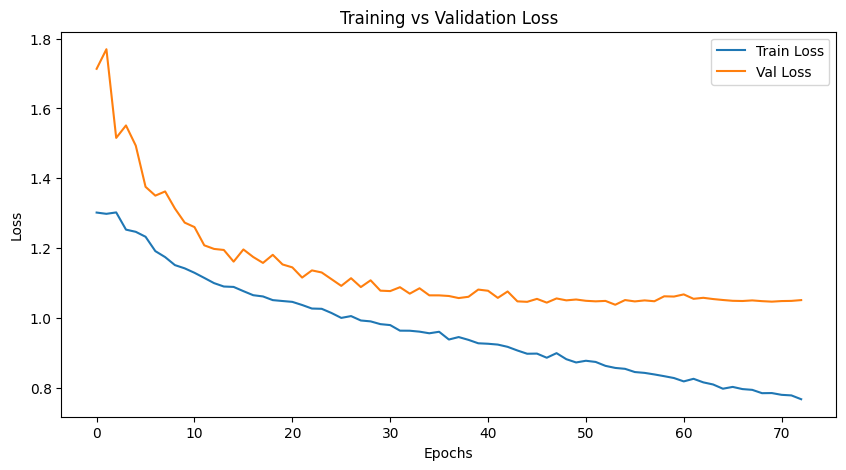

<Figure size 640x480 with 0 Axes>

In [14]:

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('runs/detect/waste_v8_fixed/results.csv')
df.columns = df.columns.str.strip()

print("Columns:", df.columns.tolist())

plt.figure(figsize=(10,5))
plt.plot(df['train/box_loss'], label='Train Loss')
plt.plot(df['val/box_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()
plt.savefig('training_graph.png')

In [16]:
from ultralytics import YOLO

model = YOLO('runs/detect/waste_v8_fixed/weights/best.pt')

metrics = model.val(data=YAML_PATH, split='test', verbose=True)

CLASS_NAMES = ['Wet_Waste', 'Dry_Waste', 'Recyclable']

Ultralytics 8.4.40 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20009MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 70.3±52.7 MB/s, size: 27.2 KB)
val: Scanning /home/btech02_06/Desktop/waste_v8_final/test/labels... 357 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 357/357 1.4Kit/s 0.3s<0.1s
val: New cache created: /home/btech02_06/Desktop/waste_v8_final/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 60, len(boxes) = 596. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 10.5it/s 2.2s0.2s
                   all        357        596      0.785      0.678      0.735      0.533
       


image 1/1 /home/btech02_06/Pictures/bc171f6be8ed72e2d97cba0f94099a44.jpg: 448x640 1 Wet_Waste, 3 Recyclables, 43.7ms
Speed: 1.2ms preprocess, 43.7ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)


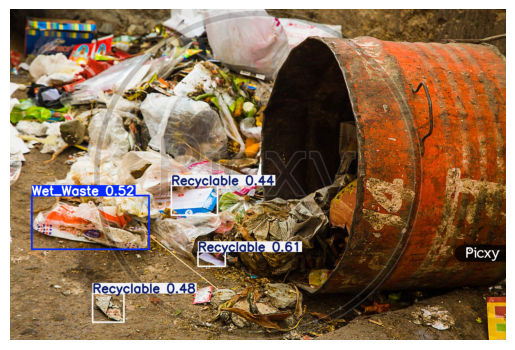

In [19]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

model = YOLO('runs/detect/waste_v8_fixed/weights/best.pt')

IMG_PATH = '/home/btech02_06/Pictures/bc171f6be8ed72e2d97cba0f94099a44.jpg'

results = model.predict(source=IMG_PATH, conf=0.25)

img = results[0].plot()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()


image 1/1 /home/btech02_06/Pictures/gettyimages-1138822598-612x612.jpg: 416x640 3 Wet_Wastes, 2 Dry_Wastes, 1 Recyclable, 43.0ms
Speed: 0.9ms preprocess, 43.0ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 640)


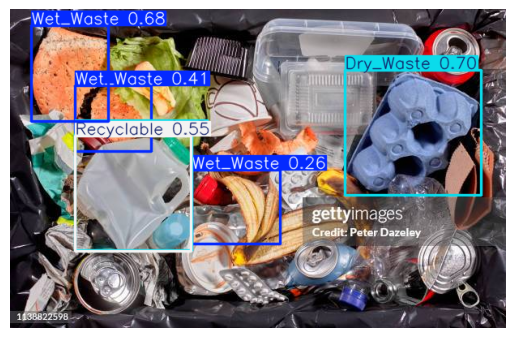

In [20]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

%matplotlib inline


model = YOLO('runs/detect/waste_v8_fixed/weights/best.pt')

IMG_PATH = '/home/btech02_06/Pictures/gettyimages-1138822598-612x612.jpg'


results = model.predict(source=IMG_PATH, conf=0.25)

img = results[0].plot()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()


image 1/1 /home/btech02_06/Pictures/green-outdoor-trash-bin-overflowing-food-scraps-plastic-bags-discarded-packaging-wet-cobblestone-street-illustrating-450848969.webp: 640x384 4 Wet_Wastes, 1 Dry_Waste, 43.5ms
Speed: 1.0ms preprocess, 43.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)


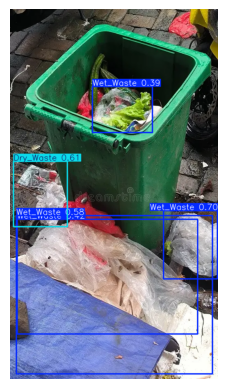

In [23]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

model = YOLO('runs/detect/waste_v8_fixed/weights/best.pt')

IMG_PATH = '/home/btech02_06/Pictures/green-outdoor-trash-bin-overflowing-food-scraps-plastic-bags-discarded-packaging-wet-cobblestone-street-illustrating-450848969.webp'

results = model.predict(source=IMG_PATH, conf=0.25)

img = results[0].plot()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()


image 1/1 /home/btech02_06/Pictures/inside-garbage-trash-can-including-260nw-2562876785.webp: 544x640 1 Dry_Waste, 1 Recyclable, 43.9ms
Speed: 1.1ms preprocess, 43.9ms inference, 0.6ms postprocess per image at shape (1, 3, 544, 640)


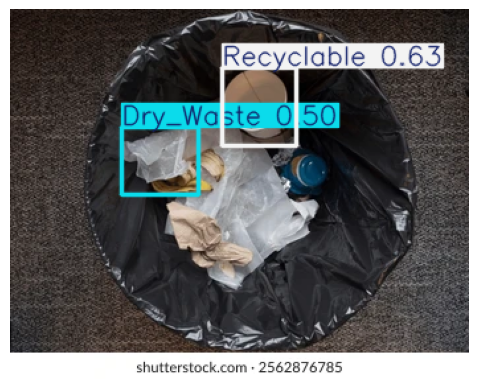

In [24]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

%matplotlib inline


model = YOLO('runs/detect/waste_v8_fixed/weights/best.pt')


IMG_PATH = '/home/btech02_06/Pictures/inside-garbage-trash-can-including-260nw-2562876785.webp'


results = model.predict(source=IMG_PATH, conf=0.25)


img = results[0].plot()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()


image 1/1 /home/btech02_06/Pictures/top-down-of-domestic-household-food-waste-in-indoor-food-recycling-BK9GNA.jpg: 480x640 7 Wet_Wastes, 2.8ms
Speed: 1.2ms preprocess, 2.8ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)


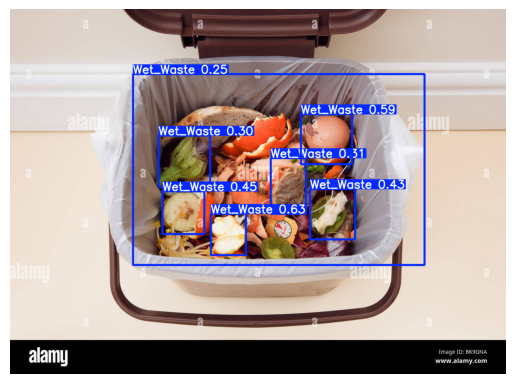

In [30]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

model = YOLO('runs/detect/waste_v8_fixed/weights/best.pt')

IMG_PATH = '/home/btech02_06/Pictures/top-down-of-domestic-household-food-waste-in-indoor-food-recycling-BK9GNA.jpg'

results = model.predict(source=IMG_PATH, conf=0.25)


img = results[0].plot()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()